In [ ]:
%%capture
!pip install "numpy<2.0"
import torch
TORCH = torch.__version__
CUDA  = torch.version.cuda or 'cpu'

!pip install torch-geometric
!pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-{TORCH}+cu{CUDA.replace('.','')}.html 2>/dev/null || true
!pip install imbalanced-learn node2vec gensim

In [ ]:
import numpy as np
import pandas as pd
import os, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch_geometric.data import Data
from torch_geometric.nn import PDNConv, GCNConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import to_scipy_sparse_matrix

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import OneClassSVM
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, precision_score,
    recall_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')
import torch_geometric; print(f'PyG    : {torch_geometric.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128
PyG    : 2.7.0


In [ ]:
nodes_df = pd.read_csv('node_features_labeled.csv')
edges_df = pd.read_csv('transactions_clean.csv')

print(f'Nodes : {len(nodes_df)}  |  Edges : {len(edges_df)}')
print(f'Phishing     : {nodes_df["label"].sum()}')
print(f'Non-phishing : {(nodes_df["label"]==0).sum()}')

node_index = {addr: i for i, addr in enumerate(nodes_df['address'])}

feat_cols = ['in_degree', 'out_degree', 'total_in', 'total_out', 'balance']
X_raw = nodes_df[feat_cols].values.astype(np.float32)

X_raw[:, 4] = np.log1p(np.abs(X_raw[:, 4])) * np.sign(X_raw[:, 4])

node_scaler = MinMaxScaler()
X_scaled = node_scaler.fit_transform(X_raw)
x = torch.tensor(X_scaled, dtype=torch.float)

y = torch.tensor(nodes_df['label'].values, dtype=torch.long)

src_list, dst_list, attr_list = [], [], []

for _, row in edges_df.iterrows():
    frm, to = row['from'], row['to']
    if frm in node_index and to in node_index:
        src_list.append(node_index[frm])
        dst_list.append(node_index[to])
        attr_list.append([
            float(row['timeStamp']),
            float(row['value']),
            float(row['blockNumber'])
        ])

edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)

ea_np = np.array(attr_list, dtype=np.float32)
edge_scaler = MinMaxScaler()
edge_attr = torch.tensor(edge_scaler.fit_transform(ea_np), dtype=torch.float)

data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
data = data.to(device)

print(f'\nPyG Graph')
print(f'  Nodes         : {data.num_nodes}')
print(f'  Edges         : {data.num_edges}')
print(f'  Node features : {data.num_node_features}')
print(f'  Edge features : {data.edge_attr.shape[1]}')
cnt = dict(zip(*[t.tolist() for t in data.y.unique(return_counts=True)]))
print(f'  Label dist.   : {cnt}')

Nodes : 17623  |  Edges : 44984
Phishing     : 88
Non-phishing : 17535

PyG Graph
  Nodes         : 17623
  Edges         : 44984
  Node features : 5
  Edge features : 3
  Label dist.   : {0: 17535, 1: 88}


In [ ]:
class PDNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, edge_dim, edge_hidden):
        super().__init__()
        self.conv = PDNConv(
            in_channels=in_channels,
            out_channels=out_channels,
            edge_dim=edge_dim,
            hidden_channels=edge_hidden
        )
        self.act  = nn.PReLU()
        self.norm = GraphNorm(out_channels)

    def forward(self, x, edge_index, edge_attr):
        x = self.conv(x, edge_index, edge_attr)
        x = self.act(x)
        x = self.norm(x)
        return x


class GAE_PDNA_Encoder(nn.Module):

    def __init__(self, in_channels, hidden_channels, out_channels,
                 edge_dim, edge_hidden, num_blocks=4):
        super().__init__()
        self.blocks = nn.ModuleList()

        self.blocks.append(
            PDNBlock(in_channels, hidden_channels, edge_dim, edge_hidden)
        )
        for _ in range(num_blocks - 1):
            self.blocks.append(
                PDNBlock(hidden_channels, hidden_channels, edge_dim, edge_hidden)
            )
        self.final_conv = PDNConv(
            in_channels=hidden_channels,
            out_channels=out_channels,
            edge_dim=edge_dim,
            hidden_channels=edge_hidden
        )

    def forward(self, x, edge_index, edge_attr):
        for block in self.blocks:
            x = block(x, edge_index, edge_attr)
        x = self.final_conv(x, edge_index, edge_attr)
        return x


class InnerProductDecoder(nn.Module):
    def forward(self, z, edge_index):
        src, dst = edge_index
        return (z[src] * z[dst]).sum(dim=1)


class GAE_PDNA(nn.Module):
    def __init__(self, in_channels, hidden_channels=32, out_channels=15,
                 edge_dim=3, edge_hidden=6, num_blocks=4):
        super().__init__()
        self.encoder = GAE_PDNA_Encoder(
            in_channels, hidden_channels, out_channels,
            edge_dim, edge_hidden, num_blocks
        )
        self.decoder = InnerProductDecoder()

    def encode(self, x, edge_index, edge_attr):
        return self.encoder(x, edge_index, edge_attr)

    def decode(self, z, edge_index):
        return self.decoder(z, edge_index)

    def forward(self, x, edge_index, edge_attr):
        return self.encode(x, edge_index, edge_attr)


_tmp = GAE_PDNA(in_channels=5)
n_params = sum(p.numel() for p in _tmp.parameters())
print(f'GAE_PDNA defined  |  {n_params:,} trainable parameters')
del _tmp

GAE_PDNA defined  |  4,398 trainable parameters


In [ ]:
transform = RandomLinkSplit(
    num_val=0.1,
    num_test=0.2,
    is_undirected=False,
    add_negative_train_samples=True,
    split_labels=True
)

train_data, val_data, test_data = transform(data.cpu())
train_data = train_data.to(device)
val_data   = val_data.to(device)
test_data  = test_data.to(device)

IN_CHANNELS     = data.num_node_features   
HIDDEN_CHANNELS = 32
OUT_CHANNELS    = 15                       
EDGE_DIM        = 3                         
EDGE_HIDDEN     = 6
NUM_BLOCKS      = 4
EPOCHS_GAE      = 100
LR_GAE          = 0.01

model_gae = GAE_PDNA(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=OUT_CHANNELS,
    edge_dim=EDGE_DIM,
    edge_hidden=EDGE_HIDDEN,
    num_blocks=NUM_BLOCKS
).to(device)

optimizer_gae = Adam(model_gae.parameters(), lr=LR_GAE)


def compute_gae_loss(model, z, pos_edge_index, neg_edge_index):
    pos_scores = model.decode(z, pos_edge_index)
    neg_scores = model.decode(z, neg_edge_index)

    pos_loss = F.binary_cross_entropy_with_logits(
        pos_scores, torch.ones_like(pos_scores)
    )
    neg_loss = F.binary_cross_entropy_with_logits(
        neg_scores, torch.zeros_like(neg_scores)
    )
    return pos_loss + neg_loss


print(f'Training GAE_PDNA for {EPOCHS_GAE} epochs ...\n')
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS_GAE + 1):
    model_gae.train()
    optimizer_gae.zero_grad()

    z = model_gae.encode(
        train_data.x, train_data.edge_index, train_data.edge_attr
    )
    loss = compute_gae_loss(
        model_gae, z,
        train_data.pos_edge_label_index,
        train_data.neg_edge_label_index
    )
    loss.backward()
    optimizer_gae.step()
    train_losses.append(loss.item())

    model_gae.eval()
    with torch.no_grad():
        z_val = model_gae.encode(
            val_data.x, val_data.edge_index, val_data.edge_attr
        )
        v_loss = compute_gae_loss(
            model_gae, z_val,
            val_data.pos_edge_label_index,
            val_data.neg_edge_label_index
        )
        val_losses.append(v_loss.item())

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}  |  Train Loss: {loss.item():.4f}  |  Val Loss: {v_loss.item():.4f}')

model_gae.eval()
with torch.no_grad():
    z_test = model_gae.encode(
        test_data.x, test_data.edge_index, test_data.edge_attr
    )
    test_loss = compute_gae_loss(
        model_gae, z_test,
        test_data.pos_edge_label_index,
        test_data.neg_edge_label_index
    )

print(f'\nFinal Train Loss : {train_losses[-1]:.4f}')
print(f'Final Val Loss   : {val_losses[-1]:.4f}')
print(f'Test Loss        : {test_loss.item():.4f}')

Training GAE_PDNA for 100 epochs ...

Epoch   1  |  Train Loss: 3.5426  |  Val Loss: 4.5392
Epoch  20  |  Train Loss: 1.0163  |  Val Loss: 1.1825
Epoch  40  |  Train Loss: 0.9551  |  Val Loss: 1.1191
Epoch  60  |  Train Loss: 0.9228  |  Val Loss: 1.1056
Epoch  80  |  Train Loss: 0.9066  |  Val Loss: 1.0862
Epoch 100  |  Train Loss: 0.8953  |  Val Loss: 1.0886

Final Train Loss : 0.8953
Final Val Loss   : 1.0886
Test Loss        : 1.0920


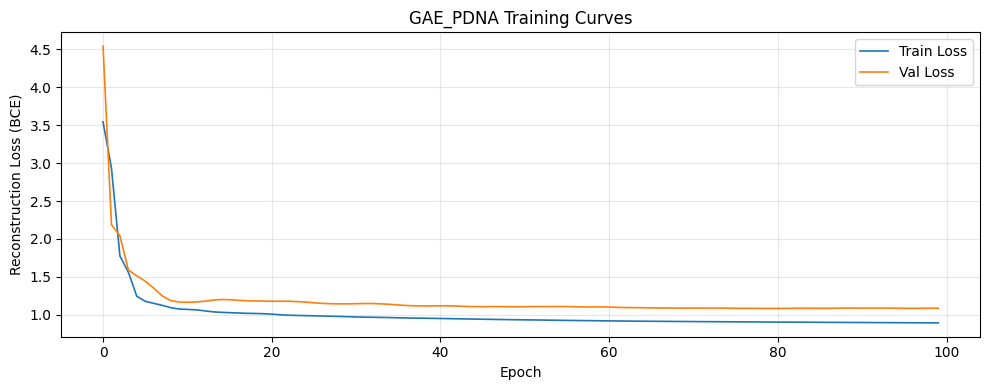

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', linewidth=1.2)
plt.plot(val_losses,   label='Val Loss',   linewidth=1.2)
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss (BCE)')
plt.title('GAE_PDNA Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
data = data.to(device)

model_gae.eval()
with torch.no_grad():
    embeddings_gae = model_gae.encode(
        data.x, data.edge_index, data.edge_attr
    ).cpu().numpy()

labels_np = data.y.cpu().numpy()

print(f'GAE_PDNA embeddings : {embeddings_gae.shape}')
print(f'  {embeddings_gae.shape[0]} nodes  x  {embeddings_gae.shape[1]} features')

GAE_PDNA embeddings : (17623, 15)
  17623 nodes  x  15 features


In [ ]:
def _build_magnetic_laplacian(edge_index, num_nodes, q_value, device):
    ei_cpu = edge_index.cpu()
    row, col = ei_cpu[0].numpy(), ei_cpu[1].numpy()
    N = num_nodes
    theta = 2.0 * np.pi * q_value

    ones = np.ones(len(row), dtype=np.float32)
    A_real = sp.coo_matrix((ones * np.cos(theta), (row, col)), shape=(N, N))
    A_imag = sp.coo_matrix((ones * np.sin(theta), (row, col)), shape=(N, N))

    A_real = (A_real + A_real.T) / 2.0
    A_imag = (A_imag - A_imag.T) / 2.0

    deg = np.array(np.abs(A_real).sum(axis=1)).flatten() + 1e-8
    D_inv_sqrt = sp.diags(1.0 / np.sqrt(deg))
    A_real_norm = D_inv_sqrt @ A_real @ D_inv_sqrt
    A_imag_norm = D_inv_sqrt @ A_imag @ D_inv_sqrt

    I_sp = sp.eye(N, dtype=np.float32)
    L_real_t = torch.tensor((I_sp - A_real_norm).toarray(), dtype=torch.float32, device=device)
    L_imag_t = torch.tensor((-A_imag_norm).toarray(),       dtype=torch.float32, device=device)
    return L_real_t, L_imag_t


class MagNetConvLayer(nn.Module):
    def __init__(self, in_channels, out_channels, K=2):
        super().__init__()
        self.K = K
        self.lin_real = nn.ModuleList([nn.Linear(in_channels, out_channels) for _ in range(K + 1)])
        self.lin_imag = nn.ModuleList([nn.Linear(in_channels, out_channels) for _ in range(K + 1)])

    def forward(self, x_real, x_imag, L_real, L_imag):
        def complex_mm(Lr, Li, xr, xi):
            return (Lr @ xr - Li @ xi, Lr @ xi + Li @ xr)

        Tx_r2, Tx_i2 = x_real, x_imag
        out_r = self.lin_real[0](Tx_r2) - self.lin_imag[0](Tx_i2)
        out_i = self.lin_real[0](Tx_i2) + self.lin_imag[0](Tx_r2)

        if self.K >= 1:
            Tx_r1, Tx_i1 = complex_mm(L_real, L_imag, x_real, x_imag)
            out_r = out_r + self.lin_real[1](Tx_r1) - self.lin_imag[1](Tx_i1)
            out_i = out_i + self.lin_real[1](Tx_i1) + self.lin_imag[1](Tx_r1)

        for k in range(2, self.K + 1):
            Tx_r, Tx_i = complex_mm(L_real, L_imag, Tx_r1, Tx_i1)
            Tx_r = 2.0 * Tx_r - Tx_r2
            Tx_i = 2.0 * Tx_i - Tx_i2
            out_r = out_r + self.lin_real[k](Tx_r) - self.lin_imag[k](Tx_i)
            out_i = out_i + self.lin_real[k](Tx_i) + self.lin_imag[k](Tx_r)
            Tx_r2, Tx_i2 = Tx_r1, Tx_i1
            Tx_r1, Tx_i1 = Tx_r, Tx_i

        return out_r, out_i


class MagNetLinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels=8, out_channels=2,
                 K=2, q=0.15, dropout=0.8):
        super().__init__()
        self.conv1 = MagNetConvLayer(in_channels, hidden_channels, K=K)
        self.conv2 = MagNetConvLayer(hidden_channels, out_channels, K=K)
        self.dropout = dropout
        self.q = nn.Parameter(torch.tensor(q, dtype=torch.float32))
        self._cached_L = None
        self._cached_q = None

    def _get_laplacian(self, edge_index, num_nodes, device):
        q_val = self.q.item()
        if self._cached_L is not None and abs(q_val - self._cached_q) < 1e-6:
            return self._cached_L
        L = _build_magnetic_laplacian(edge_index, num_nodes, q_val, device)
        self._cached_L = L
        self._cached_q = q_val
        return L

    def forward(self, x, edge_index):
        L_real, L_imag = self._get_laplacian(edge_index, x.size(0), x.device)
        x_imag = torch.zeros_like(x)
        xr, xi = self.conv1(x, x_imag, L_real, L_imag)
        xr = F.dropout(F.relu(xr), p=self.dropout, training=self.training)
        xi = F.dropout(F.relu(xi), p=self.dropout, training=self.training)
        xr, xi = self.conv2(xr, xi, L_real, L_imag)
        return xr, xi

    def decode(self, zr, zi, edge_index):
        z = torch.cat([zr, zi], dim=1)
        src, dst = edge_index
        return (z[src] * z[dst]).sum(dim=1)


model_mag = MagNetLinkPredictor(
    in_channels=data.num_node_features,
    hidden_channels=8,
    out_channels=2,
    K=2,
    q=0.15,
    dropout=0.8
).to(device)

n_params_mag = sum(p.numel() for p in model_mag.parameters())
print(f'MagNet defined  |  {n_params_mag:,} params  (custom magnetic Laplacian, K=2, q=0.15)')

optimizer_mag = Adam(model_mag.parameters(), lr=0.01)
EPOCHS_MAG = 100

print(f'Training MagNet for {EPOCHS_MAG} epochs ...\n')

for epoch in range(1, EPOCHS_MAG + 1):
    model_mag.train()
    model_mag._cached_L = None        
    optimizer_mag.zero_grad()

    zr, zi = model_mag(train_data.x, train_data.edge_index)

    pos_scores = model_mag.decode(zr, zi, train_data.pos_edge_label_index)
    neg_scores = model_mag.decode(zr, zi, train_data.neg_edge_label_index)

    scores = torch.cat([pos_scores, neg_scores])
    targets = torch.cat([
        torch.ones_like(pos_scores),
        torch.zeros_like(neg_scores)
    ])

    loss = F.binary_cross_entropy_with_logits(scores, targets)
    loss.backward()
    optimizer_mag.step()

    if epoch % 10 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}  |  Loss: {loss.item():.4f}  |  q: {model_mag.q.item():.4f}')

print(f'\nMagNet training complete.  Final q = {model_mag.q.item():.4f}')

MagNet defined  |  397 params  (custom magnetic Laplacian, K=2, q=0.15)
Training MagNet for 100 epochs ...

  Epoch   1  |  Loss: 182.9688  |  q: 0.1500
  Epoch  10  |  Loss: 19.0751  |  q: 0.1500
  Epoch  20  |  Loss: 5.8866  |  q: 0.1500
  Epoch  30  |  Loss: 2.2788  |  q: 0.1500
  Epoch  40  |  Loss: 1.3872  |  q: 0.1500
  Epoch  50  |  Loss: 1.0198  |  q: 0.1500
  Epoch  60  |  Loss: 0.9093  |  q: 0.1500
  Epoch  70  |  Loss: 0.8104  |  q: 0.1500
  Epoch  80  |  Loss: 0.7473  |  q: 0.1500
  Epoch  90  |  Loss: 0.7474  |  q: 0.1500
  Epoch 100  |  Loss: 0.7270  |  q: 0.1500

MagNet training complete.  Final q = 0.1500


In [ ]:
model_mag.eval()

with torch.no_grad():
    zr, zi = model_mag(test_data.x, test_data.edge_index)

    pos_scores = torch.sigmoid(
        model_mag.decode(zr, zi, test_data.pos_edge_label_index)
    )
    neg_scores = torch.sigmoid(
        model_mag.decode(zr, zi, test_data.neg_edge_label_index)
    )

    all_scores = torch.cat([pos_scores, neg_scores]).cpu().numpy()
    true_labels = np.concatenate([
        np.ones(pos_scores.size(0)),
        np.zeros(neg_scores.size(0))
    ])
    pred_labels = (all_scores > 0.5).astype(int)

print('MagNet Link-Prediction Results (Test Set):')
print(classification_report(true_labels, pred_labels, digits=4))

magnet_auc = roc_auc_score(true_labels, all_scores)
print(f'AUC Score: {magnet_auc:.4f}')

MagNet Link-Prediction Results (Test Set):
              precision    recall  f1-score   support

         0.0     0.2347    0.0026    0.0051      8996
         1.0     0.4985    0.9917    0.6635      8996

    accuracy                         0.4971     17992
   macro avg     0.3666    0.4971    0.3343     17992
weighted avg     0.3666    0.4971    0.3343     17992

AUC Score: 0.8699


In [ ]:
import networkx as nx
from node2vec import Node2Vec

edge_np = data.edge_index.cpu().numpy()
G_nx = nx.DiGraph()
G_nx.add_nodes_from(range(data.num_nodes))
for i in range(edge_np.shape[1]):
    G_nx.add_edge(edge_np[0, i], edge_np[1, i])

print(f'NetworkX graph: {G_nx.number_of_nodes()} nodes, '
      f'{G_nx.number_of_edges()} edges')

EMB_DIM = 15 

print('\nDeepWalk ...')
dw_walker = Node2Vec(
    G_nx, dimensions=EMB_DIM, walk_length=30,
    num_walks=200, workers=2, p=1, q=1
)
dw_model = dw_walker.fit(window=10, min_count=1, batch_words=4)

embeddings_deepwalk = np.zeros((data.num_nodes, EMB_DIM))
for nid in range(data.num_nodes):
    if str(nid) in dw_model.wv:
        embeddings_deepwalk[nid] = dw_model.wv[str(nid)]

print(f'  shape: {embeddings_deepwalk.shape}')

print('\nNode2Vec ...')
n2v_walker = Node2Vec(
    G_nx, dimensions=EMB_DIM, walk_length=30,
    num_walks=200, workers=2, p=2, q=0.5
)
n2v_model = n2v_walker.fit(window=10, min_count=1, batch_words=4)

embeddings_node2vec = np.zeros((data.num_nodes, EMB_DIM))
for nid in range(data.num_nodes):
    if str(nid) in n2v_model.wv:
        embeddings_node2vec[nid] = n2v_model.wv[str(nid)]

print(f'  shape: {embeddings_node2vec.shape}')

NetworkX graph: 17623 nodes, 25700 edges

DeepWalk ...


Computing transition probabilities:   0%|          | 0/17623 [00:00<?, ?it/s]

  shape: (17623, 15)

Node2Vec ...


Computing transition probabilities:   0%|          | 0/17623 [00:00<?, ?it/s]

  shape: (17623, 15)


In [ ]:
def balance_dataset(X, y, name=''):
    n_majority = int((y == 0).sum())
    n_minority = int((y == 1).sum())

    print(f'  [{name}]  Before: majority={n_majority}, minority={n_minority}')

    k = min(n_minority - 1, 5)
    if k < 1:
        print(f'  [{name}]  Too few minority samples for SMOTE; skipping.')
        return X, y

    smote_target = max(n_majority // 10, n_minority * 2)

    pipeline = ImbPipeline([
        ('smote', SMOTE(
            sampling_strategy={1: smote_target},
            k_neighbors=k,
            random_state=42
        )),
        ('undersample', RandomUnderSampler(
            sampling_strategy=1.0,
            random_state=42
        ))
    ])

    X_bal, y_bal = pipeline.fit_resample(X, y)
    print(f'  [{name}]  After : class_0={int((y_bal==0).sum())}, '
          f'class_1={int((y_bal==1).sum())}')
    return X_bal, y_bal


X_gae_bal, y_gae_bal = balance_dataset(embeddings_gae,      labels_np, 'GAE_PDNA')
X_dw_bal,  y_dw_bal  = balance_dataset(embeddings_deepwalk,  labels_np, 'DeepWalk')
X_n2v_bal, y_n2v_bal = balance_dataset(embeddings_node2vec,  labels_np, 'Node2Vec')

  [GAE_PDNA]  Before: majority=17535, minority=88
  [GAE_PDNA]  After : class_0=1753, class_1=1753
  [DeepWalk]  Before: majority=17535, minority=88
  [DeepWalk]  After : class_0=1753, class_1=1753
  [Node2Vec]  Before: majority=17535, minority=88
  [Node2Vec]  After : class_0=1753, class_1=1753


In [ ]:
def evaluate_classifiers(X, y, embedding_name):
    """Train & evaluate classifiers on balanced embeddings.
    Returns dict of {classifier_name: metrics_dict}.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    classifiers = {
        'AdaBoost': AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=100, random_state=42
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=42
        ),
        'Logistic Regression': LogisticRegression(
            max_iter=1000, random_state=42
        ),
        'Naive Bayes': GaussianNB(),
    }

    results = {}

    print(f'\n{"="*60}')
    print(f'  Classification Results: {embedding_name}')
    print(f'{"="*60}')

    for clf_name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        if hasattr(clf, 'predict_proba'):
            y_proba = clf.predict_proba(X_test)[:, 1]
        else:
            y_proba = y_pred.astype(float)

        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        try:
            auc = roc_auc_score(y_test, y_proba)
        except ValueError:
            auc = 0.0

        results[clf_name] = {
            'Precision': prec, 'Recall': rec,
            'F1-Score': f1, 'AUC': auc
        }

        print(f'\n--- {clf_name} ---')
        print(classification_report(y_test, y_pred, digits=4))
        print(f'AUC: {auc:.4f}')

    svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.5)
    svm.fit(X_train[y_train == 0])         
    y_svm_raw = svm.predict(X_test)
    y_svm = np.where(y_svm_raw == -1, 1, 0) 

    prec = precision_score(y_test, y_svm, zero_division=0)
    rec  = recall_score(y_test, y_svm, zero_division=0)
    f1   = f1_score(y_test, y_svm, zero_division=0)

    results['One-Class SVM'] = {
        'Precision': prec, 'Recall': rec,
        'F1-Score': f1, 'AUC': 0.0
    }

    print(f'\n--- One-Class SVM ---')
    print(classification_report(y_test, y_svm, digits=4))

    return results


results_gae = evaluate_classifiers(X_gae_bal, y_gae_bal, 'GAE_PDNA')
results_dw  = evaluate_classifiers(X_dw_bal,  y_dw_bal,  'DeepWalk')
results_n2v = evaluate_classifiers(X_n2v_bal, y_n2v_bal, 'Node2Vec')


  Classification Results: GAE_PDNA

--- AdaBoost ---
              precision    recall  f1-score   support

           0     0.8522    0.9031    0.8769       351
           1     0.8970    0.8433    0.8693       351

    accuracy                         0.8732       702
   macro avg     0.8746    0.8732    0.8731       702
weighted avg     0.8746    0.8732    0.8731       702

AUC: 0.9462

--- Random Forest ---
              precision    recall  f1-score   support

           0     0.9632    0.9687    0.9659       351
           1     0.9685    0.9630    0.9657       351

    accuracy                         0.9658       702
   macro avg     0.9658    0.9658    0.9658       702
weighted avg     0.9658    0.9658    0.9658       702

AUC: 0.9917

--- Logistic Regression ---
              precision    recall  f1-score   support

           0     0.8206    0.8860    0.8521       351
           1     0.8762    0.8063    0.8398       351

    accuracy                         0.8462       70

In [ ]:
print('=' * 65)
print('  Table 7: Performance Comparison - Embedding Algorithms')
print('  (Using AdaBoost classifier for each embedding method)')
print('=' * 65)

embed_comparison = {
    'DeepWalk': results_dw.get('AdaBoost', {}),
    'Node2Vec': results_n2v.get('AdaBoost', {}),
    'GAE_PDNA (Proposed)': results_gae.get('AdaBoost', {}),
}
df_embed = pd.DataFrame(embed_comparison).T
print(df_embed.round(4).to_string())

print(f'\n{"="*65}')
print('  Table 8: Performance Comparison - Classifiers (GAE_PDNA)')
print('=' * 65)
df_clf = pd.DataFrame(results_gae).T
print(df_clf.round(4).to_string())

print(f'\n{"="*65}')
print('  Table 6: AUC Scores')
print('=' * 65)
print(f'  MagNet (link prediction)  : {magnet_auc:.4f}')
ada_auc = results_gae.get('AdaBoost', {}).get('AUC', 0.0)
print(f'  GAE_PDNA + AdaBoost       : {ada_auc:.4f}')
rf_auc = results_gae.get('Random Forest', {}).get('AUC', 0.0)
print(f'  GAE_PDNA + Random Forest  : {rf_auc:.4f}')

  Table 7: Performance Comparison - Embedding Algorithms
  (Using AdaBoost classifier for each embedding method)
                     Precision  Recall  F1-Score     AUC
DeepWalk                0.8739  0.8889    0.8814  0.9279
Node2Vec                0.8571  0.8547    0.8559  0.9269
GAE_PDNA (Proposed)     0.8970  0.8433    0.8693  0.9462

  Table 8: Performance Comparison - Classifiers (GAE_PDNA)
                     Precision  Recall  F1-Score     AUC
AdaBoost                0.8970  0.8433    0.8693  0.9462
Random Forest           0.9685  0.9630    0.9657  0.9917
Logistic Regression     0.8762  0.8063    0.8398  0.9206
Naive Bayes             0.9073  0.6695    0.7705  0.8874
One-Class SVM           0.6288  0.8205    0.7120  0.0000

  Table 6: AUC Scores
  MagNet (link prediction)  : 0.8699
  GAE_PDNA + AdaBoost       : 0.9462
  GAE_PDNA + Random Forest  : 0.9917


Running t-SNE on balanced GAE_PDNA embeddings ...


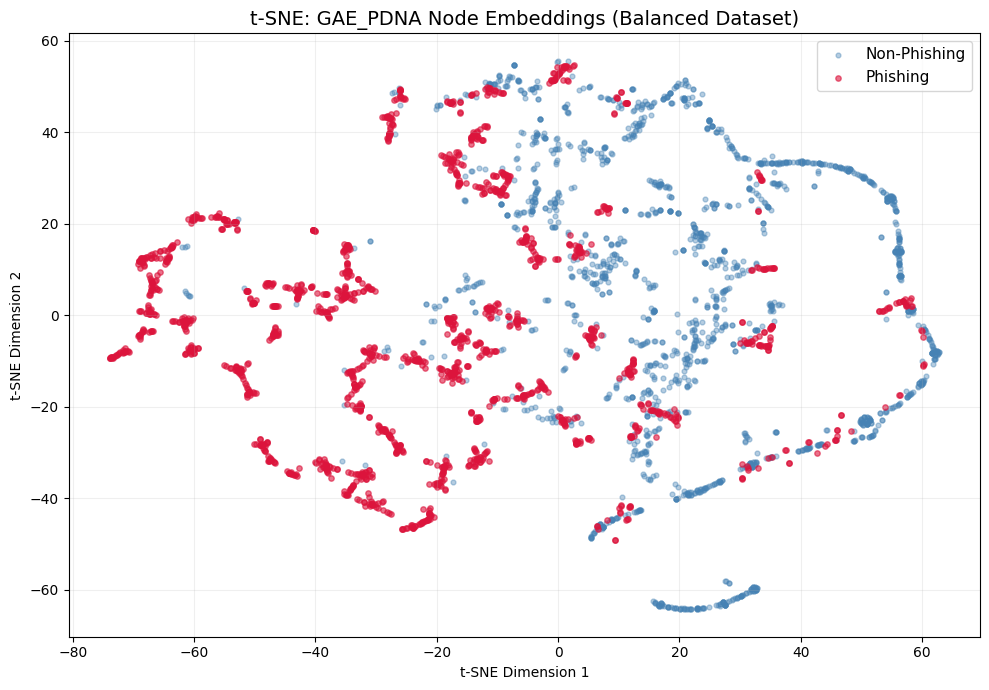

Saved: tsne_gae_pdna.png


In [ ]:

print('Running t-SNE on balanced GAE_PDNA embeddings ...')

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_gae_bal)

plt.figure(figsize=(10, 7))

mask_0 = y_gae_bal == 0
plt.scatter(X_tsne[mask_0, 0], X_tsne[mask_0, 1],
            c='steelblue', alpha=0.4, s=12, label='Non-Phishing')

mask_1 = y_gae_bal == 1
plt.scatter(X_tsne[mask_1, 0], X_tsne[mask_1, 1],
            c='crimson', alpha=0.6, s=15, label='Phishing')

plt.title('t-SNE: GAE_PDNA Node Embeddings (Balanced Dataset)', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('tsne_gae_pdna.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: tsne_gae_pdna.png')

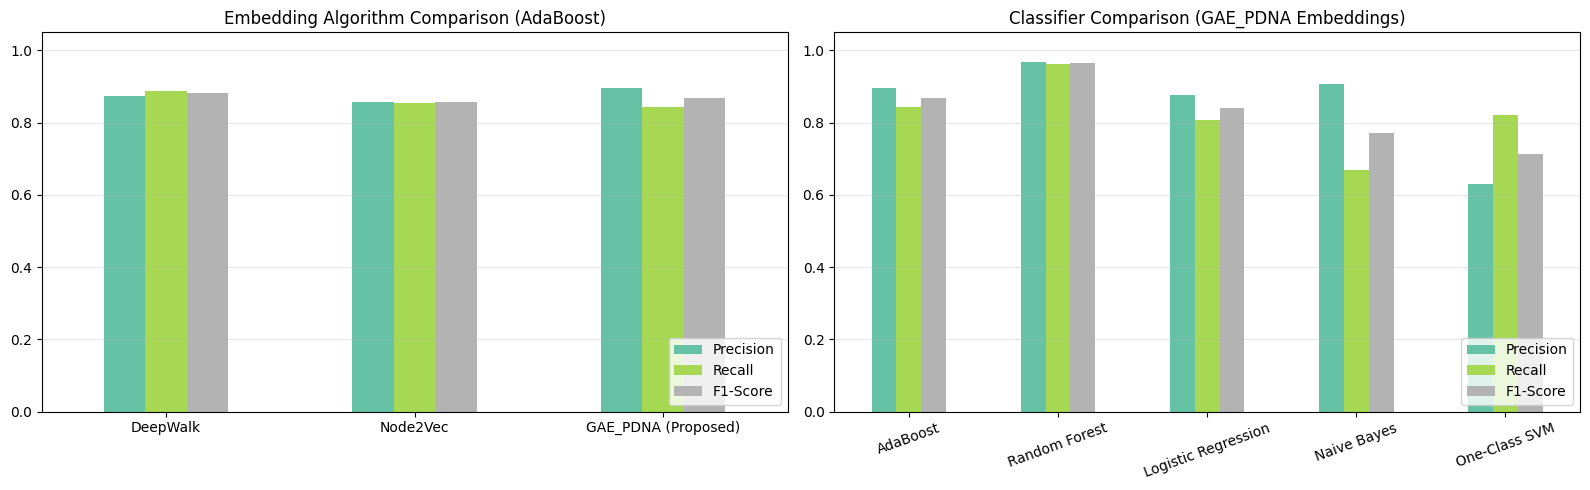

Saved: comparison_charts.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_emb_plot = pd.DataFrame(embed_comparison).T[['Precision', 'Recall', 'F1-Score']]
df_emb_plot.plot(kind='bar', ax=axes[0], rot=0, colormap='Set2')
axes[0].set_title('Embedding Algorithm Comparison (AdaBoost)')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

df_clf_plot = pd.DataFrame(results_gae).T[['Precision', 'Recall', 'F1-Score']]
df_clf_plot.plot(kind='bar', ax=axes[1], rot=20, colormap='Set2')
axes[1].set_title('Classifier Comparison (GAE_PDNA Embeddings)')
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_charts.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: comparison_charts.png')

In [ ]:
torch.save(model_gae.state_dict(), 'gae_pdna_weights.pth')
torch.save(model_mag.state_dict(), 'magnet_weights.pth')

np.save('embeddings_gae_pdna.npy',  embeddings_gae)
np.save('embeddings_deepwalk.npy',  embeddings_deepwalk)
np.save('embeddings_node2vec.npy',  embeddings_node2vec)

print('Saved files:')
print('  gae_pdna_weights.pth      - GAE_PDNA encoder weights')
print('  magnet_weights.pth        - MagNet model weights')
print('  embeddings_gae_pdna.npy   - GAE_PDNA node embeddings (15-d)')
print('  embeddings_deepwalk.npy   - DeepWalk node embeddings (15-d)')
print('  embeddings_node2vec.npy   - Node2Vec node embeddings (15-d)')

Saved files:
  gae_pdna_weights.pth      - GAE_PDNA encoder weights
  magnet_weights.pth        - MagNet model weights
  embeddings_gae_pdna.npy   - GAE_PDNA node embeddings (15-d)
  embeddings_deepwalk.npy   - DeepWalk node embeddings (15-d)
  embeddings_node2vec.npy   - Node2Vec node embeddings (15-d)


In [ ]:
from google.colab import files

for f in ['gae_pdna_weights.pth', 'magnet_weights.pth',
          'embeddings_gae_pdna.npy', 'embeddings_deepwalk.npy',
          'embeddings_node2vec.npy', 'tsne_gae_pdna.png',
          'comparison_charts.png']:
    if os.path.exists(f):
        files.download(f)
        print(f'  Downloaded: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: gae_pdna_weights.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: tsne_gae_pdna.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: comparison_charts.png
